#### Test de performance 

- Charger un fichier de 40 millions de lignes
- Exécuter une jointure ...
- Comparer avec Pandas & Polars

In [1]:
import os
import duckdb as d
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import time


In [2]:
# Vérification de la taille du fichier Parquet local
local_parquet_file = '../00_data_sources/yellow_tripdata_full_2024.parquet'
file_size_mb = os.path.getsize(local_parquet_file) / (1024 * 1024)
print(f"Taille du fichier: {file_size_mb:.2f} MB")

Taille du fichier: 807.69 MB


In [4]:
# Chargement du fichier Parquet dans DuckDB
start_time = time.time()
con = d.connect("memory")
con.execute(f"CREATE TABLE trips AS SELECT * FROM read_parquet('{local_parquet_file
}')")
duckdb_load_time = time.time() - start_time
print(f"Temps de chargement dans DuckDB: {duckdb_load_time:.2f} secondes")


Temps de chargement dans DuckDB: 7.75 secondes


In [5]:
# Chargement du fichier Parquet avec Polars

start_time = time.time()

polars_dfs = pl.read_parquet(local_parquet_file)
execution_time_polars = time.time() - start_time

# Vérifier le nombre total de trajets avec Polars
print(f"Execution time Polars: {execution_time_polars:.2f} seconds")


Execution time Polars: 5.26 seconds


In [ ]:
# Chargement du fichier Parquet avec Pandas

start_time = time.time()

trip_df = pd.read_parquet(local_parquet_file)
execution_time_polars = time.time() - start_time

# Vérifier le nombre total de trajets avec Polars
print(f"Execution time Pandas: {execution_time_pandas:.2f} seconds")


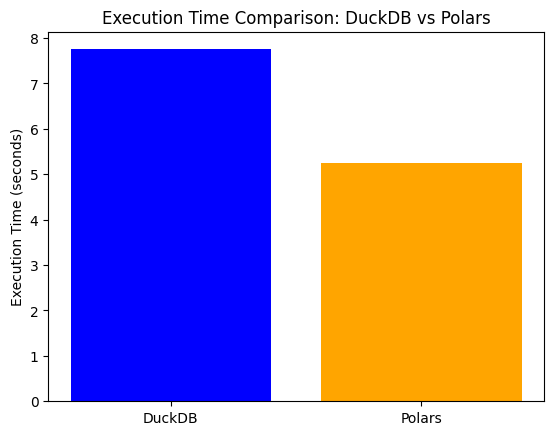

In [6]:
# Plot comparison of execution times
import matplotlib.pyplot as plt
labels = ['DuckDB', 'Polars']
times = [duckdb_load_time, execution_time_polars]
plt.bar(labels, times, color=['blue', 'orange'])
plt.ylabel('Execution Time (seconds)')
plt.title('Execution Time Comparison: DuckDB vs Polars')
plt.show()
